# ARDM-style Categorical Imputation on Fashion-MNIST

In this notebook we extend the Bernoulli MNIST model to a categorical setting using Fashion-MNIST.

Each pixel is modeled as a discrete variable taking values in {0, ..., 255}.

## Main idea

Instead of modeling each pixel as Bernoulli, we model it as:

$$
x_i \sim \text{multinomial}(p_i)
$$

where:
- the model outputs logits over 256 classes per pixel
- applying softmax gives a categorical distribution

## Training procedure

For each image:
1. Sample a random order of pixels
2. Sample a timestep \(t\)
3. Reveal the first \(t\) pixels
4. Mask the rest
5. Predict categorical distributions for missing pixels
6. Maximize likelihood (cross-entropy)

## Inference procedure

Given a partially observed image:
1. Keep observed pixels fixed
2. Generate missing pixels autoregressively
3. At each step:
   - predict logits
   - apply softmax
   - sample or argmax
4. Update image progressively

## Imports and configuration

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

Device: cuda


## Dataset

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),  # [0,1]
])

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.72MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 180kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.33MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.90MB/s]


## Categorical Fashion-MNIST dataset

Instead of binarizing the image, we convert pixel intensities into
discrete values in {0, ..., 255}.

Each pixel is treated as a categorical variable.

This allows the model to predict a distribution over 256 intensity levels.

In [3]:
class CategoricalFashionMNIST(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]

        x_cat = (x * 255).long()

        return x, x_cat, y

In [4]:
import torchvision
from torchvision import transforms

transform = transforms.ToTensor()

train_dataset = CategoricalFashionMNIST(
    torchvision.datasets.FashionMNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )
)

test_dataset = CategoricalFashionMNIST(
    torchvision.datasets.FashionMNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )
)

In [5]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

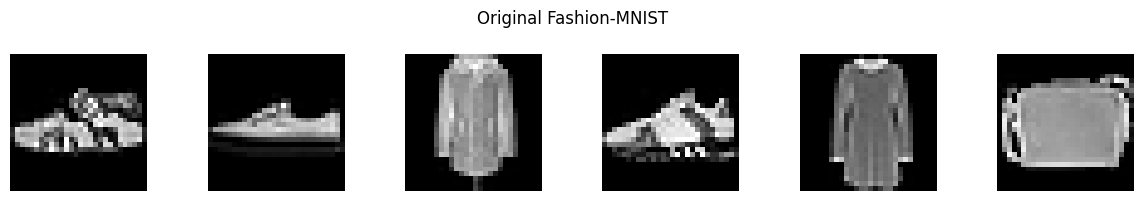

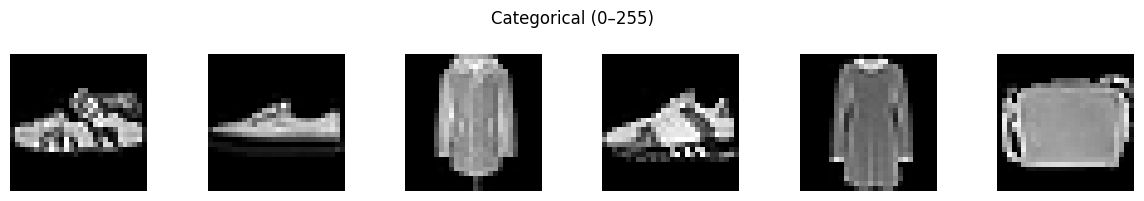

In [6]:
def show_images(images, n=6, title=None, categorical=False):
    images = images[:n].detach().cpu()

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))

    for i in range(n):
        if categorical:
            axes[i].imshow(images[i].squeeze(), cmap="gray", vmin=0, vmax=255)
        else:
            axes[i].imshow(images[i].squeeze(), cmap="gray")

        axes[i].axis("off")

    if title is not None:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()
x_batch, x_cat, y_batch = next(iter(train_loader))

show_images(x_batch, title="Original Fashion-MNIST")
show_images(x_cat, title="Categorical (0–255)", categorical=True)

## Model architecture


The model receives:
- the masked image
- the binary observation mask

These are concatenated as two input channels.

The network outputs one logit per pixel. Each logit parameterizes a multinomial distribution for that pixel.

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class LeNetCategorical(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(2, 32, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28 * 256)
        )

    def forward(self, x, mask):
        inp = torch.cat([x.float() / 255.0, mask], dim=1)
        h = self.conv(inp)
        h = h.view(h.size(0), -1)
        logits = self.fc(h)

        return logits.view(x.size(0), 256, 28, 28)

In [8]:
model = LeNetCategorical().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

LeNetCategorical(
  (conv): Sequential(
    (0): Conv2d(2, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=200704, bias=True)
  )
)


## Sampling a random order and a random timestep (categorical case)

For each image in the batch:
- sample a permutation of the 784 pixels
- sample a timestep t
- reveal the first t pixels in that order
- mask the rest

This gives the observed subset and the missing subset.

In the categorical case:
- each pixel takes values in {0, ..., 255}
- masked pixels are set to 0 (placeholder value)
- the mask indicates which pixels are observed

In [9]:
def sample_training_masks_from_random_orders(x_cat, t_min=1, t_max=None):
    """
    For each image:
    - sample a random permutation of pixels
    - sample a random t
    - reveal the first t pixels of that permutation

    Categorical version:
    - x_cat contains integer values in [0,255]
    - masked pixels are set to 0

    Returns:
        x_masked: masked categorical image (integers)
        mask_obs: observed mask (1=observed, 0=missing)
        orders: list of permutations, one per sample
        t_values: list of t values
    """
    B, C, H, W = x_cat.shape
    N = H * W

    if t_max is None:
        t_max = N - 1

    x_flat = x_cat.view(B, N)
    mask_flat = torch.zeros_like(x_flat, dtype=torch.float)

    orders = []
    t_values = []

    for b in range(B):
        order = torch.randperm(N, device=x_cat.device)

        t = torch.randint(
            low=t_min,
            high=t_max + 1,
            size=(1,),
            device=x_cat.device
        ).item()

        mask_flat[b, order[:t]] = 1.0

        orders.append(order)
        t_values.append(t)

    mask_obs = mask_flat.view(B, 1, H, W)

    x_masked = x_cat * mask_obs.long()

    return x_masked, mask_obs, orders, t_values

In [12]:
def to_categorical(x):
    """
    Convert image from [0,1] to integers in [0,255]
    """
    return (x * 255).long()

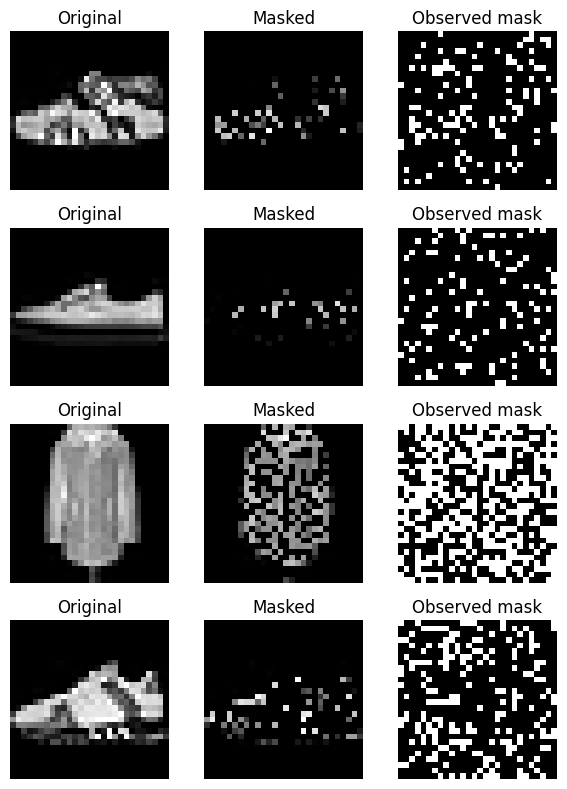

Example sampled t values: [119, 109, 400, 198, 171, 263, 641, 248]


In [13]:
# Move data to device
x = x_batch.to(device)

# convertir a categórico (0–255)
x_cat = to_categorical(x).to(device)

# Sample masks
x_masked, mask_obs, orders, t_values = sample_training_masks_from_random_orders(x_cat)

def show_triplets(original, masked, mask, n=4):
    original = original[:n].detach().cpu()
    masked = masked[:n].detach().cpu()
    mask = mask[:n].detach().cpu()

    fig, axes = plt.subplots(n, 3, figsize=(6, 2*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):

        # Original
        axes[i, 0].imshow(original[i].squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        # Masked
        axes[i, 1].imshow(masked[i].squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[i, 1].set_title("Masked")
        axes[i, 1].axis("off")

        # Mask
        axes[i, 2].imshow(mask[i].squeeze(), cmap="gray")
        axes[i, 2].set_title("Observed mask")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

show_triplets(x_cat, x_masked, mask_obs, n=4)

print("Example sampled t values:", t_values[:8])

## Categorical negative log-likelihood

The model outputs logits $z_i$ for each pixel over 256 classes.

These logits define categorical probabilities via softmax:

$$
p_i = \text{softmax}(z_i)
$$

Each pixel is modeled as:

$$
x_i \sim \text{multinomial}(p_i)
$$

The correct negative log-likelihood is the cross-entropy loss.

We compute the loss only on missing pixels, because the observed pixels are already known.

In [14]:
ce_loss = nn.CrossEntropyLoss(reduction="none")

def masked_categorical_nll(logits, target, mask_obs):
    """
    logits: [B,256,28,28]
    target: [B,1,28,28] integer image in [0,255]
    mask_obs: [B,1,28,28] 1=observed, 0=missing

    We compute cross-entropy only on missing pixels.
    """

    B, C, H, W = logits.shape

    # reshape para cross entropy
    logits = logits.permute(0, 2, 3, 1).reshape(-1, 256)   # (B*H*W, 256)
    target = target.view(-1)                                # (B*H*W)

    # mask flatten
    missing_mask = (1.0 - mask_obs).view(-1)                # (B*H*W)

    # NLL por pixel
    per_pixel_nll = ce_loss(logits, target)                 # (B*H*W)

    # evitar división por 0
    denom = missing_mask.sum().clamp(min=1.0)

    # solo en píxeles ocultos
    loss = (per_pixel_nll * missing_mask).sum() / denom

    return loss

In [15]:
model.eval()

with torch.no_grad():
    logits = model(x_masked, mask_obs)

    # usar loss categórica
    loss = masked_categorical_nll(logits, x_cat, mask_obs)

print("Logits shape:", logits.shape)
print("Example loss:", loss.item())

Logits shape: torch.Size([64, 256, 28, 28])
Example loss: 5.546800136566162


## Training loop (categorical ARDM)

At each iteration:
1. Sample a random order and a random timestep
2. Build the observation mask
3. Predict categorical logits for all pixels
4. Compute likelihood only on missing pixels
5. Backpropagate

In [16]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for _, x_cat, _ in loader:
        x_cat = x_cat.to(device)

        x_masked, mask_obs, _, _ = sample_training_masks_from_random_orders(x_cat)

        optimizer.zero_grad()

        logits = model(x_masked, mask_obs)
        loss = masked_categorical_nll(logits, x_cat, mask_obs)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [17]:
@torch.no_grad()
def evaluate_one_epoch(model, loader, device):
    model.eval()
    running_loss = 0.0

    for _, x_cat, _ in loader:
        x_cat = x_cat.to(device)

        x_masked, mask_obs, _, _ = sample_training_masks_from_random_orders(x_cat)

        logits = model(x_masked, mask_obs)
        loss = masked_categorical_nll(logits, x_cat, mask_obs)

        running_loss += loss.item()

    return running_loss / len(loader)

In [18]:
num_epochs = 20

train_losses = []
test_losses = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    test_loss = evaluate_one_epoch(model, test_loader, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"Epoch {epoch+1:02d} | train NLL: {train_loss:.4f} | test NLL: {test_loss:.4f}")

Epoch 01 | train NLL: 2.9339 | test NLL: 2.7508
Epoch 02 | train NLL: 2.6749 | test NLL: 2.6549
Epoch 03 | train NLL: 2.5947 | test NLL: 2.6016
Epoch 04 | train NLL: 2.5505 | test NLL: 2.5730
Epoch 05 | train NLL: 2.5119 | test NLL: 2.5662
Epoch 06 | train NLL: 2.4852 | test NLL: 2.5563
Epoch 07 | train NLL: 2.4624 | test NLL: 2.5496
Epoch 08 | train NLL: 2.4392 | test NLL: 2.5503
Epoch 09 | train NLL: 2.4205 | test NLL: 2.5419
Epoch 10 | train NLL: 2.4014 | test NLL: 2.5382
Epoch 11 | train NLL: 2.3854 | test NLL: 2.5374
Epoch 12 | train NLL: 2.3723 | test NLL: 2.5483
Epoch 13 | train NLL: 2.3590 | test NLL: 2.5587
Epoch 14 | train NLL: 2.3508 | test NLL: 2.5491


KeyboardInterrupt: 

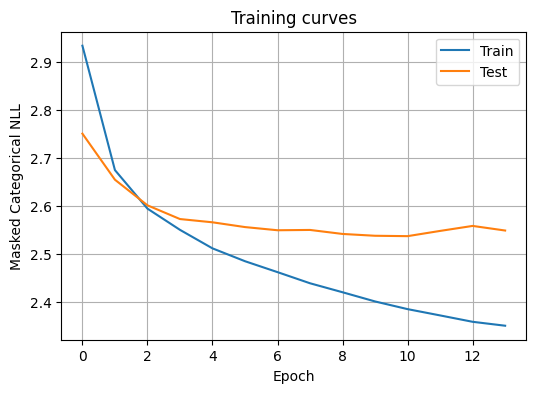

In [19]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")

plt.xlabel("Epoch")
plt.ylabel("Masked Categorical NLL")
plt.title("Training curves")

plt.legend()
plt.grid(True)
plt.show()

## One-shot imputation (categorical)

As a baseline, we impute all missing pixels in one forward pass.

Each pixel is modeled as a categorical variable over 256 intensity levels.

We obtain probabilities using softmax and then take the most likely class

This is not autoregressive, but serves as a baseline.

In [32]:
@torch.no_grad()
def one_shot_impute(model, x_masked, mask_obs, stochastic=False):
    model.eval()

    logits = model(x_masked, mask_obs)              # (B,256,H,W)
    probs = torch.softmax(logits, dim=1)            # (B,256,H,W)

    B, C, H, W = probs.shape
    probs_flat = probs.view(B, 256, -1)             # (B,256,N)

    if stochastic:
        # sample por pixel
        sampled = torch.multinomial(
            probs_flat.permute(0, 2, 1).reshape(-1, 256),
            1
        ).squeeze()

        x_pred = sampled.view(B, 1, H, W)

    else:
        # argmax (determinista)
        x_pred = torch.argmax(probs, dim=1, keepdim=True)  # (B,1,H,W)

    x_imputed = x_masked.clone()

    missing_mask = (mask_obs == 0)

    x_imputed[missing_mask] = x_pred[missing_mask]

    return x_imputed, probs

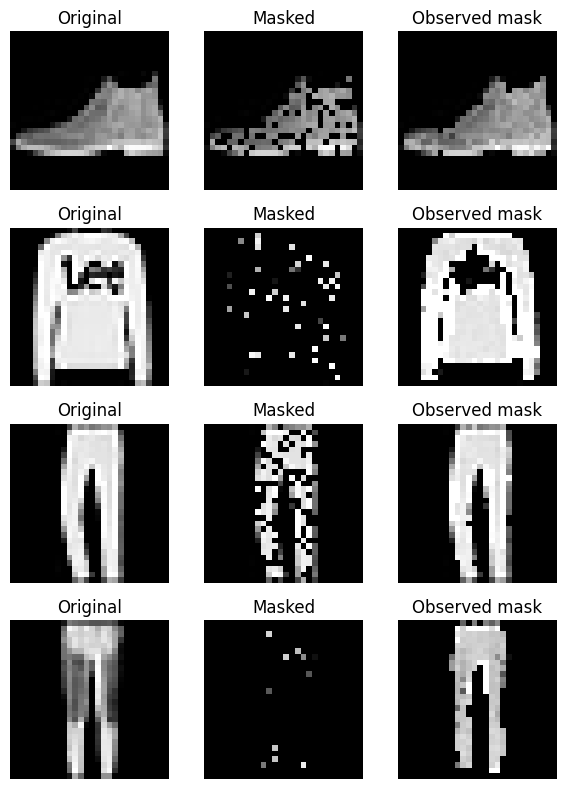

In [33]:
x_test, x_cat, _ = next(iter(test_loader))

x_test = x_test.to(device)
x_cat = x_cat.to(device)

x_masked, mask_obs, _, _ = sample_training_masks_from_random_orders(x_cat)

x_one_shot, probs = one_shot_impute(model, x_masked, mask_obs, stochastic=False)

show_triplets(x_cat, x_masked, x_one_shot, n=4)

## Autoregressive inference (categorical)

We progressively impute missing pixels using a categorical distribution.

At each step:
- compute logits
- apply softmax
- sample from categorical distribution
- update image

In [34]:
def build_inference_orders_from_mask(mask_obs):
    """
    For each image:
    - observed pixel indices come first
    - missing pixel indices come after, in random order

    Returns a list of full orders.
    """
    B, C, H, W = mask_obs.shape
    N = H * W
    mask_flat = mask_obs.view(B, N)

    orders = []

    for b in range(B):
        observed_idx = torch.where(mask_flat[b] == 1)[0]
        missing_idx = torch.where(mask_flat[b] == 0)[0]

        if len(observed_idx) > 0:
            observed_idx = observed_idx[torch.randperm(len(observed_idx), device=mask_obs.device)]
        if len(missing_idx) > 0:
            missing_idx = missing_idx[torch.randperm(len(missing_idx), device=mask_obs.device)]

        full_order = torch.cat([observed_idx, missing_idx], dim=0)
        orders.append(full_order)

    return orders

In [35]:
def random_observation_mask(x_cat, p_observed=0.3):
    mask_obs = (torch.rand_like(x_cat.float()) < p_observed).float()
    x_masked = x_cat * mask_obs.long()
    return x_masked, mask_obs

In [36]:
@torch.no_grad()
def autoregressive_impute(
    model,
    x_masked,
    mask_obs,
    orders,
    step_size=50,
    stochastic=True,
    return_history=False
):
    model.eval()

    B, C, H, W = x_masked.shape
    N = H * W

    x_current = x_masked.clone()
    mask_current = mask_obs.clone()

    history = [x_current.clone()] if return_history else None

    x_flat = x_current.view(B, N)
    mask_flat = mask_current.view(B, N)

    start_positions = []
    for b in range(B):
        start_positions.append(int(mask_flat[b].sum().item()))

    finished = [False] * B

    while not all(finished):

        logits = model(x_current, mask_current)
        probs = torch.softmax(logits, dim=1).view(B, 256, N)

        for b in range(B):

            if finished[b]:
                continue

            order = orders[b]
            start = start_positions[b]

            next_end = min(start + step_size, N)
            idx = order[start:next_end]

            if len(idx) == 0:
                finished[b] = True
                continue

            p = probs[b, :, idx].permute(1, 0)  # (k,256)

            if stochastic:
                sampled = torch.multinomial(p, 1).squeeze()
            else:
                sampled = torch.argmax(p, dim=1)

            x_flat[b, idx] = sampled
            mask_flat[b, idx] = 1

            start_positions[b] = next_end

            if next_end >= N:
                finished[b] = True

        x_current = x_flat.view(B, 1, H, W)
        mask_current = mask_flat.view(B, 1, H, W)

        if return_history:
            history.append(x_current.clone())

    if return_history:
        return x_current, mask_current, history

    return x_current, mask_current

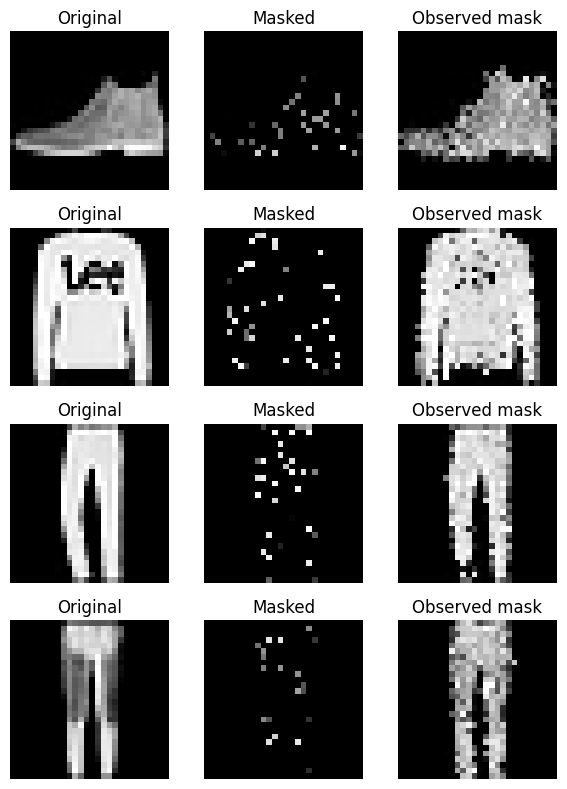

In [77]:
x_test, x_cat, _ = next(iter(test_loader))
x_test = x_test.to(device)
x_cat = x_cat.to(device)

x_masked_inf, mask_obs_inf = random_observation_mask(x_cat, p_observed=0.1)
orders_inf = build_inference_orders_from_mask(mask_obs_inf)

x_auto, final_mask, history = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=40,
    stochastic=True,
    return_history=True
)

show_triplets(x_cat, x_masked_inf, x_auto, n=4)

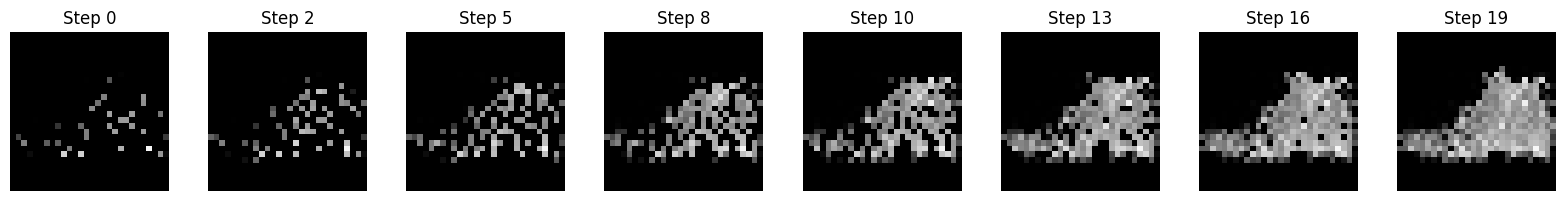

In [78]:
def show_history(history, sample_idx=0, max_panels=8):

    n_steps = len(history)
    chosen = np.linspace(0, n_steps - 1, min(n_steps, max_panels), dtype=int)

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2))

    for ax, t in zip(axes, chosen):
        ax.imshow(history[t][sample_idx].detach().cpu().squeeze(),
                  cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"Step {t}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_history(history)

In [79]:
x_det, _ = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=784,
    stochastic=False
)

x_sto, _ = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=40,
    stochastic=True
)

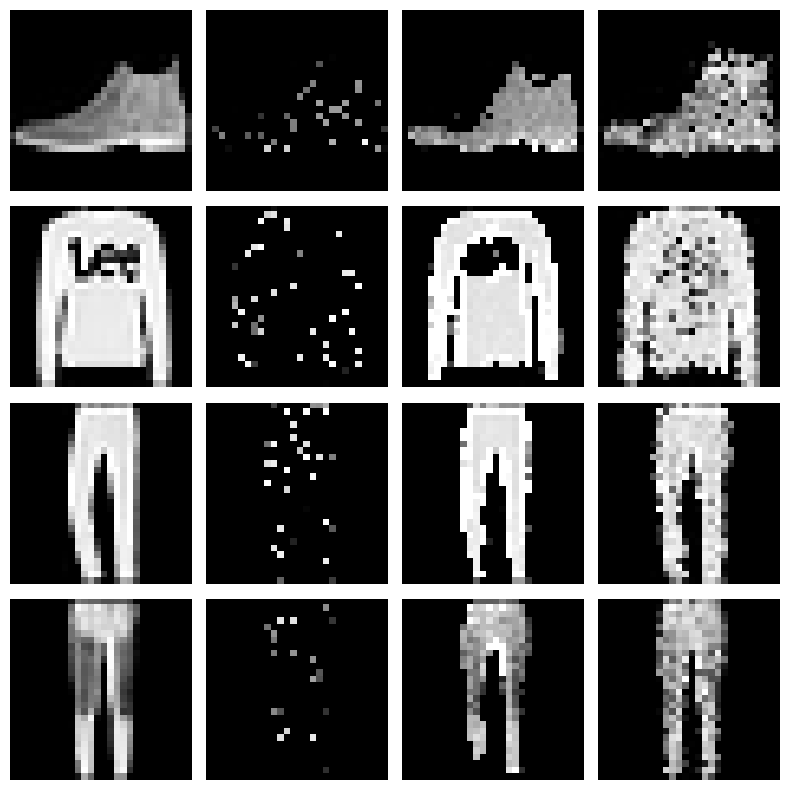

In [80]:
def show_four(original, masked, det, sto, n=4):
    fig, axes = plt.subplots(n, 4, figsize=(8, 2*n))

    for i in range(n):
        axes[i,0].imshow(original[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[i,1].imshow(masked[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[i,2].imshow(det[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[i,3].imshow(sto[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=255)

        for j in range(4):
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()

show_four(x_cat, x_masked_inf, x_det, x_sto, n=4)

## Missing pixel accuracy (categorical)

We evaluate the reconstruction quality by measuring accuracy on missing pixels only.

A prediction is considered correct if the predicted intensity exactly matches the true value (in {0, ..., 255}).

This is a stricter metric than in the binary case.

In [81]:
@torch.no_grad()
def missing_pixel_accuracy(x_true, x_pred, mask_obs):
    missing = (mask_obs == 0)
    correct = (x_true == x_pred).float()
    acc = correct[missing].mean().item()
    return acc

In [85]:
x_test, x_cat, _ = next(iter(test_loader))

x_test = x_test.to(device)
x_cat = x_cat.to(device)

x_masked_inf, mask_obs_inf = random_observation_mask(x_cat, p_observed=0.1)
orders_inf = build_inference_orders_from_mask(mask_obs_inf)

# One-shot
x_one_shot, _ = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=784,
    stochastic=False
)
# Autoregressive
x_auto_det, _ = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=16,
    stochastic=True
)

# Accuracy
acc_one_shot = missing_pixel_accuracy(x_cat, x_one_shot, mask_obs_inf)
acc_auto_det = missing_pixel_accuracy(x_cat, x_auto_det, mask_obs_inf)

print(f"One-shot missing-pixel accuracy:      {acc_one_shot:.4f}")
print(f"Autoregressive missing-pixel accuracy:{acc_auto_det:.4f}")

One-shot missing-pixel accuracy:      0.5272
Autoregressive missing-pixel accuracy:0.4609


In [86]:
@torch.no_grad()
def missing_pixel_mse(x_true, x_pred, mask_obs):
    missing = (mask_obs == 0)
    mse = ((x_true - x_pred).float() ** 2)[missing].mean().item()
    return mse

In [88]:
mse_one_shot = missing_pixel_mse(x_cat, x_one_shot, mask_obs_inf)
mse_auto_det = missing_pixel_mse(x_cat, x_auto_det, mask_obs_inf)

print(f"One-shot missing-pixel MSE:      {mse_one_shot:.4f}")
print(f"Autoregressive missing-pixel MSE: {mse_auto_det:.4f}")

One-shot missing-pixel MSE:      2858.9202
Autoregressive missing-pixel MSE: 2778.4880


## Generation steps vs MSE

We evaluate how the number of autoregressive steps affects reconstruction error
using MSE on missing pixels.

In [90]:
step_sizes = [1, 5, 10, 20, 40, 100, 784]  # 784 ≈ one-shot

In [93]:
@torch.no_grad()
def evaluate_step_size_mse(model, x_true, p_observed, step_size, stochastic=True):

    x_masked, mask_obs = random_observation_mask(x_true, p_observed=p_observed)
    orders = build_inference_orders_from_mask(mask_obs)

    x_pred, _ = autoregressive_impute(
        model,
        x_masked,
        mask_obs,
        orders,
        step_size=step_size,
        stochastic=stochastic,
        return_history=False
    )

    mse = missing_pixel_mse(x_true, x_pred, mask_obs)
    return mse

In [99]:
x_test, x_cat, _ = next(iter(test_loader))

x_test = x_test.to(device)
x_cat = x_cat.to(device)

results = []

for step_size in step_sizes:

    mse = evaluate_step_size_mse(
        model,
        x_cat,
        p_observed=0.0,
        step_size=step_size,
        stochastic=True
    )

    results.append(mse)

    print(f"step_size={step_size} → MSE={mse:.4f}")

step_size=1 → MSE=12784.2852
step_size=5 → MSE=11448.6504
step_size=10 → MSE=12571.5039
step_size=20 → MSE=11570.5020
step_size=40 → MSE=11637.6729
step_size=100 → MSE=11398.0742
step_size=784 → MSE=11175.6963


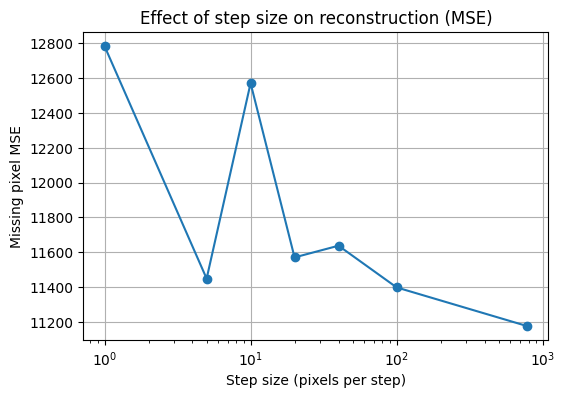

In [100]:
plt.figure(figsize=(6,4))
plt.plot(step_sizes, results, marker='o')

plt.xlabel("Step size (pixels per step)")
plt.ylabel("Missing pixel MSE")
plt.title("Effect of step size on reconstruction (MSE)")

plt.grid(True)
plt.xscale("log")

plt.show()

## Missing percentage vs model performance (categorical)

We study how reconstruction quality degrades as the percentage of missing pixels increases.

We evaluate performance using MSE on missing pixels, which is more appropriate
than accuracy in the categorical setting.

### One shot

In [98]:
@torch.no_grad()
def evaluate_observation_rate(
    model,
    x_true,
    p_observed,
    step_size=10,
    stochastic=False
):
    """
    Evaluate final missing-pixel MSE for a given observation probability.
    """

    x_masked, mask_obs = random_observation_mask(x_true, p_observed=p_observed)
    orders = build_inference_orders_from_mask(mask_obs)

    x_pred, _ = autoregressive_impute(
        model,
        x_masked,
        mask_obs,
        orders,
        step_size=step_size,
        stochastic=stochastic,
        return_history=False
    )

    mse = missing_pixel_mse(x_true, x_pred, mask_obs)

    return mse, x_masked, x_pred, mask_obs

In [101]:
p_observed_values = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]


In [102]:
x_test, x_cat, _ = next(iter(test_loader))

x_test = x_test.to(device)
x_cat = x_cat.to(device)

In [103]:
results_mse = []
results_missing = []

for p_obs in p_observed_values:

    mse, _, _, _ = evaluate_observation_rate(
        model,
        x_cat,
        p_observed=p_obs,
        step_size=784,   # one-shot
        stochastic=False
    )

    missing_fraction = 1.0 - p_obs

    results_mse.append(mse)
    results_missing.append(missing_fraction)

    print(f"Observed: {p_obs:.2f} | Missing: {missing_fraction:.2f} | MSE: {mse:.4f}")

Observed: 0.10 | Missing: 0.90 | MSE: 3066.5510
Observed: 0.20 | Missing: 0.80 | MSE: 2479.2336
Observed: 0.30 | Missing: 0.70 | MSE: 2174.1479
Observed: 0.50 | Missing: 0.50 | MSE: 2288.0889
Observed: 0.70 | Missing: 0.30 | MSE: 2021.8937
Observed: 0.90 | Missing: 0.10 | MSE: 1813.0590


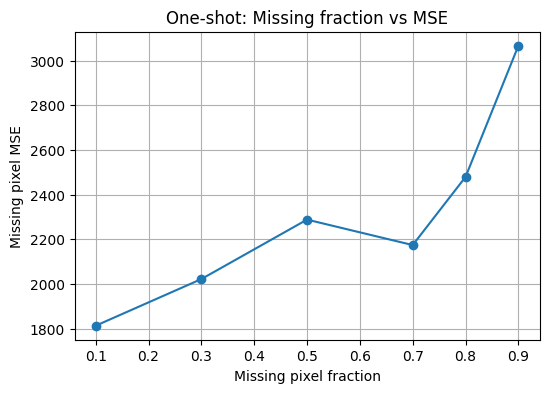

In [104]:
plt.figure(figsize=(6,4))
plt.plot(results_missing, results_mse, marker='o')

plt.xlabel("Missing pixel fraction")
plt.ylabel("Missing pixel MSE")
plt.title("One-shot: Missing fraction vs MSE")

plt.grid(True)
plt.show()

### Autorregresive

In [105]:
results_mse = []
results_missing = []

for p_obs in p_observed_values:

    mse, _, _, _ = evaluate_observation_rate(
        model,
        x_cat,
        p_observed=p_obs,
        step_size=10,   # autoregresivo
        stochastic=True
    )

    missing_fraction = 1.0 - p_obs

    results_mse.append(mse)
    results_missing.append(missing_fraction)

    print(f"Observed: {p_obs:.2f} | Missing: {missing_fraction:.2f} | MSE: {mse:.4f}")

Observed: 0.10 | Missing: 0.90 | MSE: 2805.6511
Observed: 0.20 | Missing: 0.80 | MSE: 2464.6619
Observed: 0.30 | Missing: 0.70 | MSE: 2306.6150
Observed: 0.50 | Missing: 0.50 | MSE: 2213.5859
Observed: 0.70 | Missing: 0.30 | MSE: 2106.6860
Observed: 0.90 | Missing: 0.10 | MSE: 1987.5273


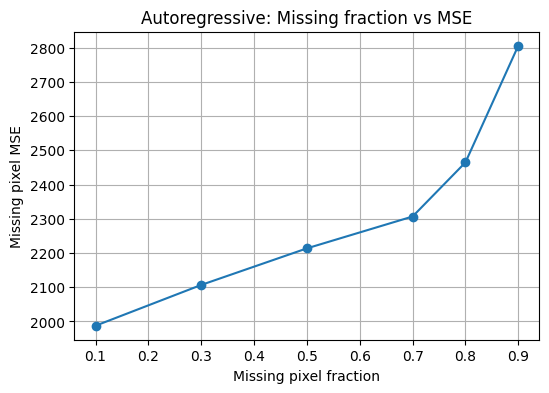

In [106]:
plt.figure(figsize=(6,4))
plt.plot(results_missing, results_mse, marker='o')

plt.xlabel("Missing pixel fraction")
plt.ylabel("Missing pixel MSE")
plt.title("Autoregressive: Missing fraction vs MSE")

plt.grid(True)
plt.show()

### Cool figures

In [107]:
@torch.no_grad()
def get_probabilities(model, x_current, mask_current):
    logits = model(x_current, mask_current)
    probs = torch.softmax(logits, dim=1)
    return probs

In [108]:
def get_confidence_map(probs, x_pred):
    """
    Returns probability assigned to predicted class
    """
    B, C, H, W = probs.shape

    # indices del valor predicho
    idx = x_pred.long()

    # gather probabilidad correcta
    confidence = torch.gather(probs, 1, idx)

    return confidence  # shape (B,1,H,W)

In [109]:
def show_reconstruction_with_probs(
    x_true,
    x_masked,
    x_pred,
    confidence,
    n=5
):
    fig, axes = plt.subplots(n, 4, figsize=(10, 2*n))

    for i in range(n):

        axes[i,0].imshow(x_true[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[i,0].set_title("Original")
        axes[i,0].axis("off")

        axes[i,1].imshow(x_masked[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[i,1].set_title("Masked")
        axes[i,1].axis("off")

        axes[i,2].imshow(x_pred[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[i,2].set_title("Reconstruction")
        axes[i,2].axis("off")

        axes[i,3].imshow(
            confidence[i].cpu().squeeze(),
            cmap="viridis",
            vmin=0,
            vmax=1
        )
        axes[i,3].set_title("Confidence")
        axes[i,3].axis("off")

    plt.tight_layout()
    plt.show()

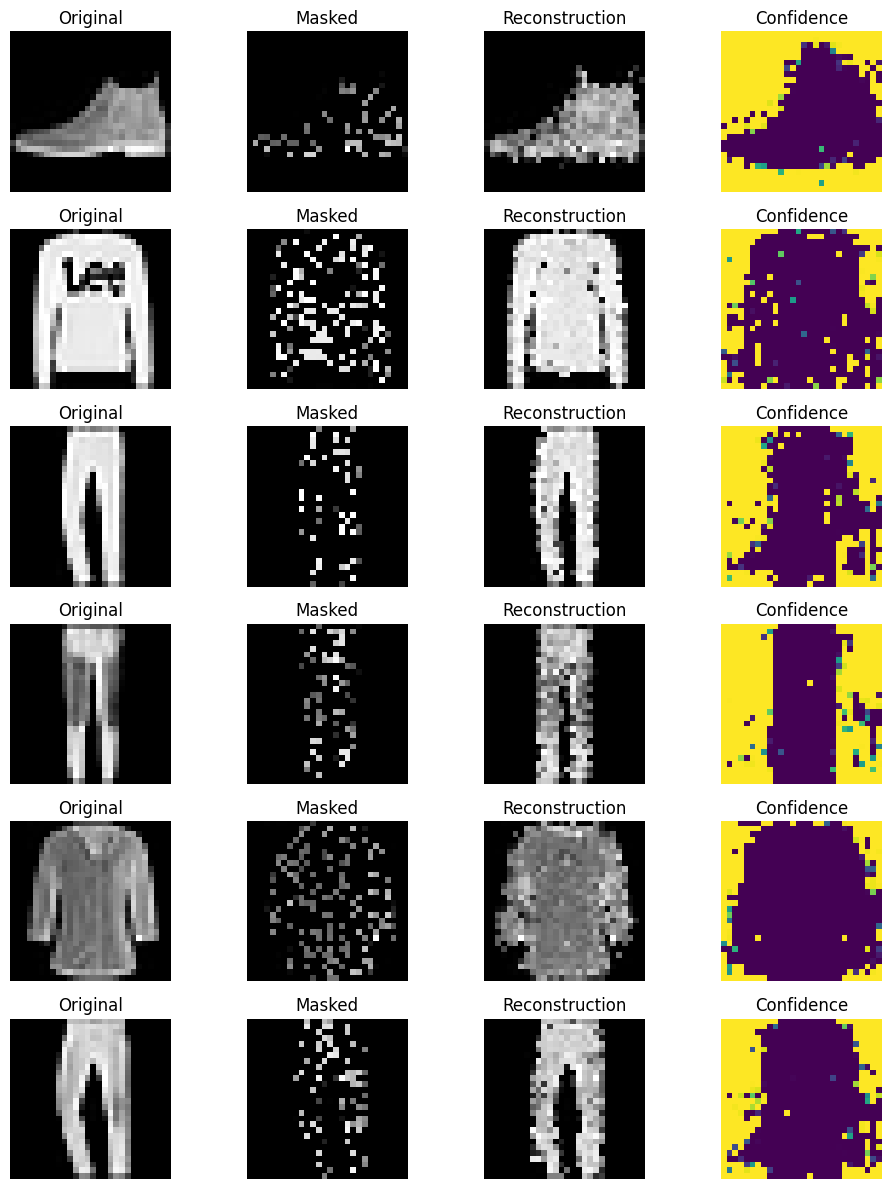

In [111]:
x_test, x_cat, _ = next(iter(test_loader))

x_test = x_test.to(device)
x_cat = x_cat.to(device)

x_masked, mask_obs = random_observation_mask(x_cat, p_observed=0.25)
orders = build_inference_orders_from_mask(mask_obs)

x_pred, _ = autoregressive_impute(
    model,
    x_masked,
    mask_obs,
    orders,
    step_size=1,
    stochastic=True
)

probs = get_probabilities(model, x_pred, mask_obs)

confidence = get_confidence_map(probs, x_pred)

show_reconstruction_with_probs(
    x_cat,
    x_masked,
    x_pred,
    confidence,
    n=6
)